# Analisys

## Source golden tables

In [1]:
gold_source = (
    "/home/baptvit/Documents/mestrado/master-experiments/evaluations/data/gold/microsoft/"
)

In [2]:
import glob
import os

import pandas as pd

all_files = glob.glob(os.path.join(gold_source, "*.csv"))

df_gold = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)

In [3]:
df_gold.columns

Index(['consumer_id', 'experiment_1', 'expriment_1_name', 'experiment_2',
       'expriment_2_name', 'experiment_1_output', 'experiment_2_output',
       'model_evaluation', 'response', 'comprehensiveness', 'diversity',
       'empowerment', 'directness', 'overall_winner'],
      dtype='object')

In [4]:
target_df = df_gold[
    [
        "consumer_id",
        "experiment_1",
        "experiment_2",
        "expriment_1_name",
        "expriment_2_name",
        "comprehensiveness",
        "diversity",
        "empowerment",
        "directness",
        "overall_winner",
    ]
]

### Count by the answer 

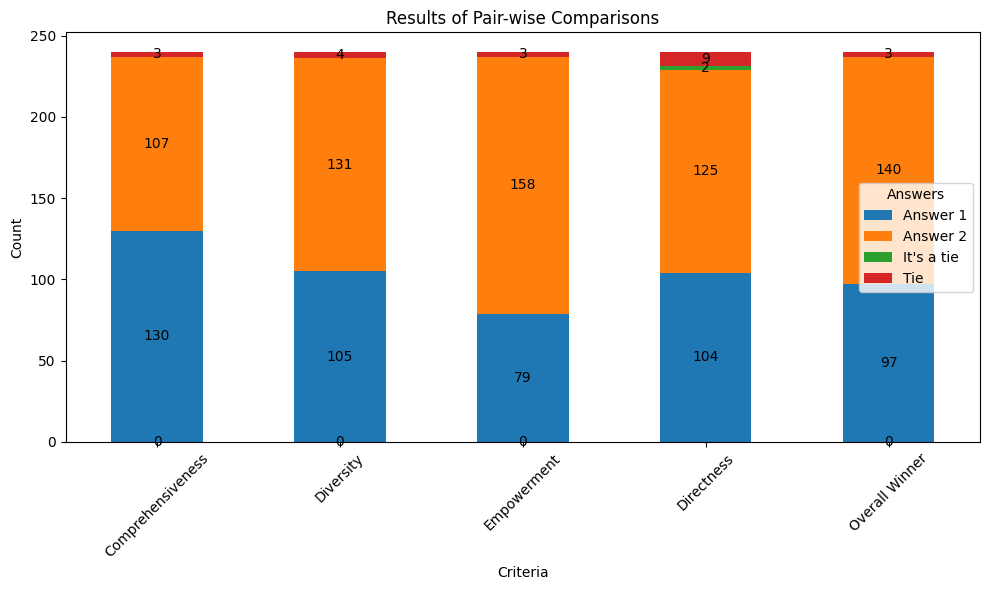

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Count the number of times Answer 1 and Answer 2 were chosen for each criterion
counts = {
    criterion: target_df[criterion].value_counts()
    for criterion in [
        "comprehensiveness",
        "diversity",
        "empowerment",
        "directness",
        "overall_winner",
    ]
}

# Convert counts into a DataFrame for plotting
count_df = pd.DataFrame(counts).fillna(0)

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

# Create a bar plot
count_df.T.plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Results of Pair-wise Comparisons")
ax.set_ylabel("Count")
ax.set_xlabel("Criteria")
ax.legend(title="Answers")
ax.set_xticklabels(
    ["Comprehensiveness", "Diversity", "Empowerment", "Directness", "Overall Winner"],
    rotation=45,
)

# Adding value on top of each bar
for i, bars in enumerate(ax.containers):
    ax.bar_label(bars, label_type="center")

plt.tight_layout()
plt.show()

### Resume analisys

In [6]:
def count_wins(df, answer):
    count_dict = {}
    for column in [
        "comprehensiveness",
        "diversity",
        "empowerment",
        "directness",
        "overall_winner",
    ]:
        count_dict[column] = (df[column] == answer).sum()
    return count_dict


# Count wins for "Answer 1" and "Answer 2"
answer1_wins = count_wins(target_df, "Answer 1")
answer2_wins = count_wins(target_df, "Answer 2")


# Overall stats
def print_analysis():
    print("Analysis of Pair-wise Comparison Results:")
    print("\nTotal comparisons:", len(target_df))
    print("\nAnswer 1 Wins by Criterion:")
    for criterion, count in answer1_wins.items():
        print(f"  {criterion.capitalize()}: {count}")

    print("\nAnswer 2 Wins by Criterion:")
    for criterion, count in answer2_wins.items():
        print(f"  {criterion.capitalize()}: {count}")

    print("\nOverall Strategy Performance:")
    overall_1_wins = target_df[target_df["overall_winner"] == "Answer 1"]
    overall_2_wins = target_df[target_df["overall_winner"] == "Answer 2"]

    strategy_performance = (
        target_df.groupby(["expriment_1_name", "expriment_2_name", "overall_winner"])
        .size()
        .unstack(fill_value=0)
    )
    print(strategy_performance)


print_analysis()

Analysis of Pair-wise Comparison Results:

Total comparisons: 240

Answer 1 Wins by Criterion:
  Comprehensiveness: 130
  Diversity: 105
  Empowerment: 79
  Directness: 104
  Overall_winner: 97

Answer 2 Wins by Criterion:
  Comprehensiveness: 107
  Diversity: 131
  Empowerment: 158
  Directness: 125
  Overall_winner: 140

Overall Strategy Performance:
overall_winner                                             Answer 1  Answer 2  \
expriment_1_name             expriment_2_name                                   
LexicalSearch0HopStrategy    SimilaritySearch1HopStrategy        18        22   
LexicalSearch1HopStrategy    LexicalSearch0HopStrategy           22        17   
                             SimilaritySearch0HopStrategy        22        18   
                             SimilaritySearch1HopStrategy        19        21   
SimilaritySearch0HopStrategy LexicalSearch0HopStrategy           10        30   
                             SimilaritySearch1HopStrategy         6        32 

### Comparacao head-to-head

In [7]:
# Function to calculate the head-to-head scores
def calculate_scores(df):
    # Dictionary to store the results
    results = {}

    # Iterate through the rows and accumulate the scores
    for index, row in df.iterrows():
        exp1 = row["expriment_1_name"]
        exp2 = row["expriment_2_name"]

        if (exp1, exp2) not in results:
            results[(exp1, exp2)] = {"exp1_wins": 0, "exp2_wins": 0}

        # Check who wins more criteria
        criteria = ["comprehensiveness", "diversity", "empowerment", "directness"]
        for criterion in criteria:
            if row[criterion] == "Answer 1":
                results[(exp1, exp2)]["exp1_wins"] += 1
            elif row[criterion] == "Answer 2":
                results[(exp1, exp2)]["exp2_wins"] += 1

    return results


# Calculate scores
comparison_results = calculate_scores(target_df)

# Print the results
for pair, scores in comparison_results.items():
    exp1, exp2 = pair
    print(f"Comparison between {exp1} and {exp2}:")
    print(f" - {exp1} wins: {scores['exp1_wins']} times")
    print(f" - {exp2} wins: {scores['exp2_wins']} times")
    print()

Comparison between LexicalSearch1HopStrategy and SimilaritySearch0HopStrategy:
 - LexicalSearch1HopStrategy wins: 91 times
 - SimilaritySearch0HopStrategy wins: 68 times

Comparison between LexicalSearch1HopStrategy and LexicalSearch0HopStrategy:
 - LexicalSearch1HopStrategy wins: 80 times
 - LexicalSearch0HopStrategy wins: 75 times

Comparison between LexicalSearch1HopStrategy and SimilaritySearch1HopStrategy:
 - LexicalSearch1HopStrategy wins: 82 times
 - SimilaritySearch1HopStrategy wins: 76 times

Comparison between SimilaritySearch0HopStrategy and LexicalSearch0HopStrategy:
 - SimilaritySearch0HopStrategy wins: 46 times
 - LexicalSearch0HopStrategy wins: 110 times

Comparison between SimilaritySearch0HopStrategy and SimilaritySearch1HopStrategy:
 - SimilaritySearch0HopStrategy wins: 46 times
 - SimilaritySearch1HopStrategy wins: 106 times

Comparison between LexicalSearch0HopStrategy and SimilaritySearch1HopStrategy:
 - LexicalSearch0HopStrategy wins: 73 times
 - SimilaritySearch1

### Vencedor geral

In [8]:
# Function to count wins for each experiment
def calculate_win_rates(df):
    win_rates = {}

    for index, row in df.iterrows():
        exp1 = row["expriment_1_name"]
        exp2 = row["expriment_2_name"]

        if exp1 not in win_rates:
            win_rates[exp1] = 0
        if exp2 not in win_rates:
            win_rates[exp2] = 0

        # Check who won the overall category
        winner = row["overall_winner"]
        if winner == "Answer 1":
            win_rates[exp1] += 1
        elif winner == "Answer 2":
            win_rates[exp2] += 1

    return win_rates


# Calculate the win rates
win_rates = calculate_win_rates(target_df)

# Convert win rates to percentages if needed
total_matches = target_df.shape[0]
win_percentage = {k: (v / total_matches) * 100 for k, v in win_rates.items()}

# Display the results
print("Win Rates (as percentages based on overall winner):")
for experiment, percentage in win_percentage.items():
    print(f"{experiment}: {percentage:.2f}%")

Win Rates (as percentages based on overall winner):
LexicalSearch1HopStrategy: 26.25%
SimilaritySearch0HopStrategy: 14.17%
LexicalSearch0HopStrategy: 27.08%
SimilaritySearch1HopStrategy: 31.25%


### Vencedor geral - comprehensiveness

In [30]:
# Function to count wins for each experiment
def calculate_win_rates(df):
    win_rates = {}

    for index, row in df.iterrows():
        exp1 = row["expriment_1_name"]
        exp2 = row["expriment_2_name"]

        if exp1 not in win_rates:
            win_rates[exp1] = 0
        if exp2 not in win_rates:
            win_rates[exp2] = 0

        # Check who won the overall category
        winner = row["comprehensiveness"]
        if winner == "Answer 1":
            win_rates[exp1] += 1
        elif winner == "Answer 2":
            win_rates[exp2] += 1

    return win_rates


# Calculate the win rates
win_rates = calculate_win_rates(target_df)

# Convert win rates to percentages if needed
total_matches = target_df.shape[0]
win_percentage = {k: (v / total_matches) * 100 for k, v in win_rates.items()}

# Display the results
print("Win Rates (as percentages based on Comprehensiveness):")
for experiment, percentage in win_percentage.items():
    print(f"{experiment}: {percentage:.2f}%")

Win Rates (as percentages based on Comprehensiveness):
LexicalSearch1HopStrategy: 35.42%
SimilaritySearch0HopStrategy: 15.83%
LexicalSearch0HopStrategy: 21.67%
SimilaritySearch1HopStrategy: 25.83%


### Vencedor geral - diversity

In [31]:
# Function to count wins for each experiment
def calculate_win_rates(df):
    win_rates = {}

    for index, row in df.iterrows():
        exp1 = row["expriment_1_name"]
        exp2 = row["expriment_2_name"]

        if exp1 not in win_rates:
            win_rates[exp1] = 0
        if exp2 not in win_rates:
            win_rates[exp2] = 0

        # Check who won the overall category
        winner = row["diversity"]
        if winner == "Answer 1":
            win_rates[exp1] += 1
        elif winner == "Answer 2":
            win_rates[exp2] += 1

    return win_rates


# Calculate the win rates
win_rates = calculate_win_rates(target_df)

# Convert win rates to percentages if needed
total_matches = target_df.shape[0]
win_percentage = {k: (v / total_matches) * 100 for k, v in win_rates.items()}

# Display the results
print("Win Rates (as percentages based on Diversity):")
for experiment, percentage in win_percentage.items():
    print(f"{experiment}: {percentage:.2f}%")

Win Rates (as percentages based on Diversity):
LexicalSearch1HopStrategy: 25.83%
SimilaritySearch0HopStrategy: 16.25%
LexicalSearch0HopStrategy: 27.50%
SimilaritySearch1HopStrategy: 28.75%


### Vencedor geral - empowerment

In [11]:
# Function to count wins for each experiment
def calculate_win_rates(df):
    win_rates = {}

    for index, row in df.iterrows():
        exp1 = row["expriment_1_name"]
        exp2 = row["expriment_2_name"]

        if exp1 not in win_rates:
            win_rates[exp1] = 0
        if exp2 not in win_rates:
            win_rates[exp2] = 0

        # Check who won the overall category
        winner = row["empowerment"]
        if winner == "Answer 1":
            win_rates[exp1] += 1
        elif winner == "Answer 2":
            win_rates[exp2] += 1

    return win_rates


# Calculate the win rates
win_rates = calculate_win_rates(target_df)

# Convert win rates to percentages if needed
total_matches = target_df.shape[0]
win_percentage = {k: (v / total_matches) * 100 for k, v in win_rates.items()}

# Display the results
print("Win Rates (as percentages based on Empowerment):")
for experiment, percentage in win_percentage.items():
    print(f"{experiment}: {percentage:.2f}%")

Win Rates (as percentages based on Empowerment):
LexicalSearch1HopStrategy: 21.67%
SimilaritySearch0HopStrategy: 15.00%
LexicalSearch0HopStrategy: 28.33%
SimilaritySearch1HopStrategy: 33.75%


### Vencedor geral - Directness

In [12]:
# Function to count wins for each experiment
def calculate_win_rates(df):
    win_rates = {}

    for index, row in df.iterrows():
        exp1 = row["expriment_1_name"]
        exp2 = row["expriment_2_name"]

        if exp1 not in win_rates:
            win_rates[exp1] = 0
        if exp2 not in win_rates:
            win_rates[exp2] = 0

        # Check who won the overall category
        winner = row["directness"]
        if winner == "Answer 1":
            win_rates[exp1] += 1
        elif winner == "Answer 2":
            win_rates[exp2] += 1

    return win_rates


# Calculate the win rates
win_rates = calculate_win_rates(target_df)

# Convert win rates to percentages if needed
total_matches = target_df.shape[0]
win_percentage = {k: (v / total_matches) * 100 for k, v in win_rates.items()}

# Display the results
print("Win Rates (as percentages based on Directness):")
for experiment, percentage in win_percentage.items():
    print(f"{experiment}: {percentage:.2f}%")

Win Rates (as percentages based on Directness):
LexicalSearch1HopStrategy: 22.50%
SimilaritySearch0HopStrategy: 19.58%
LexicalSearch0HopStrategy: 30.00%
SimilaritySearch1HopStrategy: 23.33%


### Vencedor geral - Overall winner

In [13]:
# Function to count wins for each experiment
def calculate_win_rates(df):
    win_rates = {}

    for index, row in df.iterrows():
        exp1 = row["expriment_1_name"]
        exp2 = row["expriment_2_name"]

        if exp1 not in win_rates:
            win_rates[exp1] = 0
        if exp2 not in win_rates:
            win_rates[exp2] = 0

        # Check who won the overall category
        winner = row["overall_winner"]
        if winner == "Answer 1":
            win_rates[exp1] += 1
        elif winner == "Answer 2":
            win_rates[exp2] += 1

    return win_rates


# Calculate the win rates
win_rates = calculate_win_rates(target_df)

# Convert win rates to percentages if needed
total_matches = target_df.shape[0]
win_percentage = {k: (v / total_matches) * 100 for k, v in win_rates.items()}

# Display the results
print("Win Rates (as percentages based on Overall winner):")
for experiment, percentage in win_percentage.items():
    print(f"{experiment}: {percentage:.2f}%")

Win Rates (as percentages based on Overall winner):
LexicalSearch1HopStrategy: 26.25%
SimilaritySearch0HopStrategy: 14.17%
LexicalSearch0HopStrategy: 27.08%
SimilaritySearch1HopStrategy: 31.25%


### Matrix comparacao

In [14]:
columns_test = [
    "SimilaritySearch0HopStrategy",
    "SimilaritySearch1HopStrategy",
    "LexicalSearch0HopStrategy",
    "LexicalSearch1HopStrategy",
]

pd.DataFrame(index=columns_test, columns=columns_test, data=0)

,SimilaritySearch0HopStrategy,SimilaritySearch1HopStrategy,LexicalSearch0HopStrategy,LexicalSearch1HopStrategy
SimilaritySearch0HopStrategy,0,0,0,0
SimilaritySearch1HopStrategy,0,0,0,0
LexicalSearch0HopStrategy,0,0,0,0
LexicalSearch1HopStrategy,0,0,0,0


#### Comprehensiveness

In [26]:
# Initialize an empty dataframe to hold the comparison matrix
comparison_matrix = pd.DataFrame(index=columns_test, columns=columns_test, data=0)

# Criteria to compare
criteria = ["comprehensiveness"]

# Compute the pairwise comparison
for index, row in target_df.iterrows():
    exp1 = row["expriment_1_name"]
    exp2 = row["expriment_2_name"]

    # Calculate scores based on which answer won per criterion
    exp1_score = sum(1 for criterion in criteria if row[criterion] == "Answer 1")
    exp2_score = sum(1 for criterion in criteria if row[criterion] == "Answer 2")

    # Update matrix based on scores, adding to the current value
    comparison_matrix.at[exp1, exp2] += exp2_score
    comparison_matrix.at[exp2, exp1] += exp1_score

# Fill diagonal with NaN because comparing the same experiment yields no information
# np.fill_diagonal(comparison_matrix.values, np.nan)

comparison_matrix

,SimilaritySearch0HopStrategy,SimilaritySearch1HopStrategy,LexicalSearch0HopStrategy,LexicalSearch1HopStrategy
SimilaritySearch0HopStrategy,0,27,25,28
SimilaritySearch1HopStrategy,11,0,19,26
LexicalSearch0HopStrategy,15,21,0,31
LexicalSearch1HopStrategy,12,14,8,0


In [16]:
comparison_matrix.to_dict()

{'SimilaritySearch0HopStrategy': {'SimilaritySearch0HopStrategy': 0,
  'SimilaritySearch1HopStrategy': 11,
  'LexicalSearch0HopStrategy': 15,
  'LexicalSearch1HopStrategy': 12},
 'SimilaritySearch1HopStrategy': {'SimilaritySearch0HopStrategy': 27,
  'SimilaritySearch1HopStrategy': 0,
  'LexicalSearch0HopStrategy': 21,
  'LexicalSearch1HopStrategy': 14},
 'LexicalSearch0HopStrategy': {'SimilaritySearch0HopStrategy': 25,
  'SimilaritySearch1HopStrategy': 19,
  'LexicalSearch0HopStrategy': 0,
  'LexicalSearch1HopStrategy': 8},
 'LexicalSearch1HopStrategy': {'SimilaritySearch0HopStrategy': 28,
  'SimilaritySearch1HopStrategy': 26,
  'LexicalSearch0HopStrategy': 31,
  'LexicalSearch1HopStrategy': 0}}

#### All

In [32]:
# Initialize an empty dataframe to hold the comparison matrix
comparison_matrix = pd.DataFrame(index=columns_test, columns=columns_test, data=0)

# Criteria to compare
criteria = [
    "comprehensiveness",
    "diversity",
    "empowerment",
    "directness",
    "overall_winner",
]

# Compute the pairwise comparison
for index, row in target_df.iterrows():
    exp1 = row["expriment_1_name"]
    exp2 = row["expriment_2_name"]

    # Calculate scores based on which answer won per criterion
    exp1_score = sum([1 for criterion in criteria if row[criterion] == "Answer 1"])
    exp2_score = sum([1 for criterion in criteria if row[criterion] == "Answer 2"])

    # Update matrix based on scores, adding to the current value
    comparison_matrix.at[exp1, exp2] += exp2_score
    comparison_matrix.at[exp2, exp1] += exp1_score

# Fill diagonal with NaN because comparing the same experiment yields no information
# np.fill_diagonal(comparison_matrix.values, np.nan)

comparison_matrix

,SimilaritySearch0HopStrategy,SimilaritySearch1HopStrategy,LexicalSearch0HopStrategy,LexicalSearch1HopStrategy
SimilaritySearch0HopStrategy,0,138,140,113
SimilaritySearch1HopStrategy,52,0,91,101
LexicalSearch0HopStrategy,56,108,0,102
LexicalSearch1HopStrategy,86,97,92,0


In [33]:
comparison_matrix.to_dict()

{'SimilaritySearch0HopStrategy': {'SimilaritySearch0HopStrategy': 0,
  'SimilaritySearch1HopStrategy': 52,
  'LexicalSearch0HopStrategy': 56,
  'LexicalSearch1HopStrategy': 86},
 'SimilaritySearch1HopStrategy': {'SimilaritySearch0HopStrategy': 138,
  'SimilaritySearch1HopStrategy': 0,
  'LexicalSearch0HopStrategy': 108,
  'LexicalSearch1HopStrategy': 97},
 'LexicalSearch0HopStrategy': {'SimilaritySearch0HopStrategy': 140,
  'SimilaritySearch1HopStrategy': 91,
  'LexicalSearch0HopStrategy': 0,
  'LexicalSearch1HopStrategy': 92},
 'LexicalSearch1HopStrategy': {'SimilaritySearch0HopStrategy': 113,
  'SimilaritySearch1HopStrategy': 101,
  'LexicalSearch0HopStrategy': 102,
  'LexicalSearch1HopStrategy': 0}}

#### Resumo geral

In [34]:
# Initialize a DataFrame to hold the pairwise scores
experiments = np.unique(target_df[["expriment_1_name", "expriment_2_name"]].values)
pairwise_matrix = pd.DataFrame(0, index=experiments, columns=experiments)


# Function to update the pairwise matrix
def update_scores(row):
    criteria = [
        "comprehensiveness",
        "diversity",
        "empowerment",
        "directness",
        "overall_winner",
    ]

    for criterion in criteria:
        answer1 = "Answer 1"
        answer2 = "Answer 2"

        if row[criterion] == answer1:
            pairwise_matrix.loc[row["expriment_1_name"], row["expriment_2_name"]] += 1
        elif row[criterion] == answer2:
            pairwise_matrix.loc[row["expriment_2_name"], row["expriment_1_name"]] += 1


# Iterate over each row in the DataFrame and update scores accordingly
target_df.apply(update_scores, axis=1)

# Display the resulting pairwise comparison matrix
print("Pairwise comparison matrix:")
print(pairwise_matrix)

# Calculate rankings: count of criteria won over alternative strategies
total_wins = pairwise_matrix.sum(axis=1)
rankings = total_wins.rank(ascending=False)

print("\nTotal wins by each experiment strategy:")
print(total_wins)

print("\nRanking of each experiment strategy:")
print(rankings)

Pairwise comparison matrix:
                              LexicalSearch0HopStrategy  \
LexicalSearch0HopStrategy                             0   
LexicalSearch1HopStrategy                           102   
SimilaritySearch0HopStrategy                         56   
SimilaritySearch1HopStrategy                        108   

                              LexicalSearch1HopStrategy  \
LexicalSearch0HopStrategy                            92   
LexicalSearch1HopStrategy                             0   
SimilaritySearch0HopStrategy                         86   
SimilaritySearch1HopStrategy                         97   

                              SimilaritySearch0HopStrategy  \
LexicalSearch0HopStrategy                              140   
LexicalSearch1HopStrategy                              113   
SimilaritySearch0HopStrategy                             0   
SimilaritySearch1HopStrategy                           138   

                              SimilaritySearch1HopStrategy  
LexicalS

#### Overall analisys per question

In [35]:
target_df.columns

Index(['consumer_id', 'experiment_1', 'experiment_2', 'expriment_1_name',
       'expriment_2_name', 'comprehensiveness', 'diversity', 'empowerment',
       'directness', 'overall_winner'],
      dtype='object')

In [36]:
experiments_name = np.unique(target_df[["experiment_1", "experiment_2"]].values)

In [37]:
questions = ()

In [38]:
list_question = list(set([expertiment.split(":")[0] for expertiment in experiments_name]))

In [39]:
list_question.sort()

In [40]:
target_df.loc[target_df["experiment_1"].str.contains(list_question[0])]

,consumer_id,experiment_1,experiment_2,expriment_1_name,expriment_2_name,comprehensiveness,diversity,empowerment,directness,overall_winner
42,Allen322_Ferry570_ad134528-56a5-35fd-c37f-466f...,Q1:gemini-1.5-pro:lexical_search_1_hop,Q1:gemini-1.5-pro:similarity_search_0_hop,LexicalSearch1HopStrategy,SimilaritySearch0HopStrategy,Answer 1,Answer 2,Answer 2,Answer 1,Answer 1
43,Allen322_Ferry570_ad134528-56a5-35fd-c37f-466f...,Q1:gemini-1.5-pro:lexical_search_1_hop,Q1:gemini-1.5-pro:lexical_search_0_hop,LexicalSearch1HopStrategy,LexicalSearch0HopStrategy,Answer 2,Answer 1,Answer 2,Answer 2,Answer 2
44,Allen322_Ferry570_ad134528-56a5-35fd-c37f-466f...,Q1:gemini-1.5-pro:lexical_search_1_hop,Q1:gemini-1.5-pro:similarity_search_1_hop,LexicalSearch1HopStrategy,SimilaritySearch1HopStrategy,Answer 1,Answer 2,Answer 2,Answer 2,Answer 2
45,Allen322_Ferry570_ad134528-56a5-35fd-c37f-466f...,Q1:gemini-1.5-pro:similarity_search_0_hop,Q1:gemini-1.5-pro:lexical_search_0_hop,SimilaritySearch0HopStrategy,LexicalSearch0HopStrategy,Answer 2,Answer 2,Answer 2,Answer 2,Answer 2
46,Allen322_Ferry570_ad134528-56a5-35fd-c37f-466f...,Q1:gemini-1.5-pro:similarity_search_0_hop,Q1:gemini-1.5-pro:similarity_search_1_hop,SimilaritySearch0HopStrategy,SimilaritySearch1HopStrategy,Answer 2,Answer 1,Answer 2,Answer 1,Answer 2
47,Allen322_Ferry570_ad134528-56a5-35fd-c37f-466f...,Q1:gemini-1.5-pro:lexical_search_0_hop,Q1:gemini-1.5-pro:similarity_search_1_hop,LexicalSearch0HopStrategy,SimilaritySearch1HopStrategy,Answer 1,Answer 2,Answer 2,Answer 2,Answer 2
90,Beatris270_Bogan287_5b3645de-a2d0-d016-0839-ba...,Q1:gemini-1.5-pro:lexical_search_1_hop,Q1:gemini-1.5-pro:similarity_search_0_hop,LexicalSearch1HopStrategy,SimilaritySearch0HopStrategy,Answer 1,Answer 1,Answer 1,Answer 2,Answer 1
91,Beatris270_Bogan287_5b3645de-a2d0-d016-0839-ba...,Q1:gemini-1.5-pro:lexical_search_1_hop,Q1:gemini-1.5-pro:lexical_search_0_hop,LexicalSearch1HopStrategy,LexicalSearch0HopStrategy,Answer 1,Answer 1,Answer 1,Answer 2,Answer 1
92,Beatris270_Bogan287_5b3645de-a2d0-d016-0839-ba...,Q1:gemini-1.5-pro:lexical_search_1_hop,Q1:gemini-1.5-pro:similarity_search_1_hop,LexicalSearch1HopStrategy,SimilaritySearch1HopStrategy,Answer 2,Answer 2,Answer 2,Answer 1,Answer 2
93,Beatris270_Bogan287_5b3645de-a2d0-d016-0839-ba...,Q1:gemini-1.5-pro:similarity_search_0_hop,Q1:gemini-1.5-pro:lexical_search_0_hop,SimilaritySearch0HopStrategy,LexicalSearch0HopStrategy,Answer 2,Answer 2,Answer 2,Answer 2,Answer 2


In [41]:
# Function to update the pairwise matrix
def analys_by_question(list_question, target_df):
    def update_scores(row):
        criteria = [
            "comprehensiveness",
            "diversity",
            "empowerment",
            "directness",
            "overall_winner",
        ]

        for criterion in criteria:
            answer1 = "Answer 1"
            answer2 = "Answer 2"

            if row[criterion] == answer1:
                pairwise_matrix.loc[row["expriment_1_name"], row["expriment_2_name"]] += 1
            elif row[criterion] == answer2:
                pairwise_matrix.loc[row["expriment_2_name"], row["expriment_1_name"]] += 1

    # Iterate over each row in the DataFrame and update scores accordingly

    for question in list_question:
        print(f"Start analysis for question: {question}")
        # Initialize a DataFrame to hold the pairwise scores
        experiments = np.unique(
            target_df[["expriment_1_name", "expriment_2_name"]].values
        )
        pairwise_matrix = pd.DataFrame(0, index=experiments, columns=experiments)

        df_question = target_df.loc[target_df["experiment_1"].str.contains(question)]

        df_question.apply(update_scores, axis=1)

        # Display the resulting pairwise comparison matrix
        print(f"Pairwise comparison matrix for question number {question}:")
        print(pairwise_matrix)

        # Calculate rankings: count of criteria won over alternative strategies
        total_wins = pairwise_matrix.sum(axis=1)
        rankings = total_wins.rank(ascending=False)

        print(f"\nTotal wins by each experiment strategy for question number {question}:")
        print(total_wins)

        print(f"\nRanking of each experiment strategy for question number {question}:")
        print(rankings)
        print(f"Finish analysis for question: {question}\n\n\n\n")


analys_by_question(list_question, target_df)

Start analysis for question: Q1
Pairwise comparison matrix for question number Q1:
                              LexicalSearch0HopStrategy  \
LexicalSearch0HopStrategy                             0   
LexicalSearch1HopStrategy                            13   
SimilaritySearch0HopStrategy                          8   
SimilaritySearch1HopStrategy                         21   

                              LexicalSearch1HopStrategy  \
LexicalSearch0HopStrategy                            12   
LexicalSearch1HopStrategy                             0   
SimilaritySearch0HopStrategy                         13   
SimilaritySearch1HopStrategy                         20   

                              SimilaritySearch0HopStrategy  \
LexicalSearch0HopStrategy                               17   
LexicalSearch1HopStrategy                               12   
SimilaritySearch0HopStrategy                             0   
SimilaritySearch1HopStrategy                            21   

              